# Tilaajien käyttäytymisen K-means-segmentointi PROC FASTCLUSilla


## Tiivistelmä

Tässä muistikirjassa segmentoidaan synteettinen 100 matkapuhelinliittymän joukko käyttäytymisklustereihin `PROC FASTCLUS`illa, joka on Base SAS:n k-means-klusterointiproseduuri. Seitsemän käyttömuuttujaa standardoidaan z-pisteiksi `PROC STDIZE`llä, jotta suurimittakaavaiset muuttujat (puheminuutit, tekstiviestimäärät) eivät hallitse euklidista etäisyyttä, minkä jälkeen `PROC FASTCLUS` sovittaa kolme klusteria. Proseduuri raportoi klusterin sisäisen RMS-poikkeaman, kokonais-R-neliön ja pseudo-F:n, jotka kuvaavat kuinka hyvin segmentointi erottelee joukon (tässä kokonais-R-neliö on 0,575 ja pseudo-F 65,75), ja kirjoittaa pisteytetyn taulukon, jossa jokaisella tilaajalla on `CLUSTER`-tunniste. Yhdistämme nämä tunnisteet takaisin alkuperäisen mittakaavan dataan, profiloimme persoonat ja luovutamme luokittelut jatkokäsittelyyn.

## Datalähteet

| Datajoukko | Kuvaus | Rivit | Avainmuuttujat |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Synteettinen kuukausittainen käyttäytymissnapshot matkapuhelinoperaattorin tilaajajoukolle, generoitu suoraan `call streaminit` / `rand()`-funktioilla. Kolme piilevää käyttäytymistyyppiä (paljon dataa käyttävät, puhekeskeiset, vähän käyttävät) sekoitetaan kohinalla. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nimellinen), `region` (nimellinen) |

# Tilaajien käyttäytymisen K-means-segmentointi

**Toimiala:** Televiestintä &nbsp;|&nbsp; **Proseduuri:** `PROC FASTCLUS` (Base SAS:n k-means-klusterointi)

Matkapuhelinoperaattoreilla on tilaajia, joiden kuukausittainen käyttäytyminen -- dataruokahalu, puhetottumukset, kulutus ja tukipyyntöjen määrä -- jakautuu muutamaan tunnistettavaan kaavaan. Näiden kaavojen löytäminen antaa liiketoiminnalle mahdollisuuden räätälöidä asiakaspysyvyystoimia, myydä oikeita paketteja lisää ja hankkia samankaltaisia uusia asiakkaita. Tämä muistikirja rakentaa käyttäytymissegmentoinnin päästä päähän: generoi realistisen tilaajasnapshotin, standardoi muuttujat, antaa `PROC FASTCLUS`in sovittaa klusterit, pisteyttää jokaisen tilaajan ja profiloi segmentit toimintakelpoisiksi persooniksi. `PROC FASTCLUS` on suunniteltu juuri tähän erillisten joukkojen k-means-tehtävään ja skaalautuu erittäin suuriin joukkoihin käymällä datan läpi kerran sen sijaan, että rakentaisi täyden etäisyysmatriisin.

## 1. Synteettisen tilaajajoukon generointi

Simuloimme 100 tilaajaa, jotka on poimittu kolmesta piilevästä käyttäytymisarkkityypistä -- **paljon dataa suoratoistavat**, **puhekeskeiset perinteikkäät** ja **kevyen/vähäisen käytön** asiakkaat -- ja sekoitamme mukaan kohinaa, jotta rajat ovat sumeat (kuten todellisuudessakin). Jokaisella tilaajalla on myös kaksi kategorista ominaisuutta, `data_plan` ja `region`, joita käytämme myöhemmin segmenttien *profilointiin*. Siemenluku tekee datasta toistettavan.

In [1]:
/* -----------------------------------------------------------
   Synteettinen matkapuhelintilaajien snapshot (100 riviä).
   Kolme piilevää käyttäytymisarkkityyppiä + kohinaa, lisäksi
   kaksi kategorista ominaisuutta segmenttien profilointiin.
   ----------------------------------------------------------- */
TIEDOT subscribers;
    CALL streaminit(20260531);

    PITUUS data_plan $16 region $12;

    TEE subscriber_id = 100001 ASTI 100100;

        /* piilevä arkkityyppi: 1=paljon dataa, 2=puhe, 3=vähän käyttöä */
        u = rand('uniform');
        JOS      u < 0.38 NIIN archetype = 1;
        MUUTEN JOS u < 0.70 NIIN archetype = 2;
        MUUTEN                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        JOS archetype = 1 NIIN TEE;             /* paljon dataa suoratoistava */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        LOPPU;
        MUUTEN JOS archetype = 2 NIIN TEE;        /* puhekeskeinen */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        LOPPU;
        MUUTEN TEE;                              /* vähäinen käyttö */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        LOPPU;

        JOS planpick = 1 NIIN data_plan = 'Prepaid';
        MUUTEN JOS planpick = 2 NIIN data_plan = 'Jälkikäteinen';
        MUUTEN data_plan = 'Rajaton';

        region_pick = rand('table', 0.30, 0.28, 0.22, 0.20);
        JOS region_pick = 1 NIIN region = 'Pohjoinen';
        MUUTEN JOS region_pick = 2 NIIN region = 'Etelä';
        MUUTEN JOS region_pick = 3 NIIN region = 'Itä';
        MUUTEN region = 'Länsi';

        /* pyöristys siistiä raportointitarkkuutta varten */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        TULOSTE;
    LOPPU;

    SÄILYTÄ subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
SUORITA;



NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Tarkastele muuttujien jakaumia

Ennen klusterointia katsotaan jokaisen käyttäytymismuuttujan mittakaavaa ja hajontaa. Hyvin erilaiset yksiköt -- gigatavut, minuutit, dollarit, lukumäärät -- ovat juuri syy, miksi intervallimuuttujat standardoidaan ennen klusterointia; muuten suurimittakaavaiset muuttujat kuten `voice_minutes` hallitsisivat euklidista etäisyyttä, jota `PROC FASTCLUS` minimoi.

                                                  The MEANS Procedure

 Variable         Label                    N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -----------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Asiakkuus (kk)         100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Data (Gt/kk)           100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Puheminuutit           100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Tekstiviestit          100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Ulkomaanminuutit       100        45.1        53.0         0.0              7


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


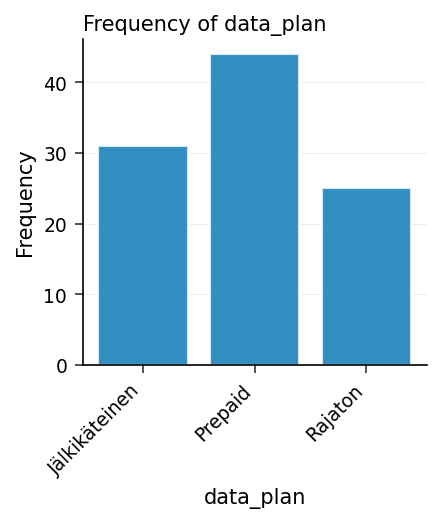

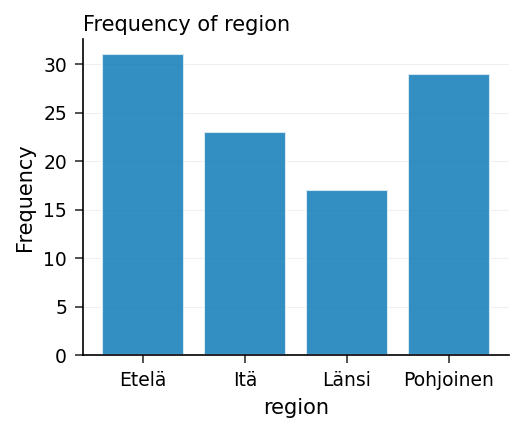

In [2]:
/* Yhteenvetotilastot klusteroinnin syötemuuttujille */
PROSEDUURI KESKIARVOT TIEDOT=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    NIMIKE tenure_months='Asiakkuus (kk)' monthly_data_gb='Data (Gt/kk)'
          voice_minutes='Puheminuutit' sms_count='Tekstiviestit'
          intl_minutes='Ulkomaanminuutit' arpu='ARPU ($)'
          support_calls='Tukipyynnöt';
    MUUTTUJA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SUORITA;

/* Kahden kategorisen muuttujan frekvenssit */
PROSEDUURI FREKVENSSIT TIEDOT=subscribers;
    NIMIKE data_plan='Liittymätyyppi' region='Alue';
    TABLES data_plan region / nocum;
SUORITA;


## 3. Muuttujien standardointi z-pisteiksi

`PROC FASTCLUS` minimoi euklidista etäisyyttä, joten sadoissa minuuteissa mitattu muuttuja hukuttaisi yksinumeroisina gigatavuina mitatun muuttujan. `PROC STDIZE`, jossa `METHOD=STD`, skaalaa jokaisen intervallimuuttujan keskiarvoon 0 ja keskihajontaan 1, jolloin jokainen käyttäytymispiirre saa yhtäläisen painon etäisyydessä. Kategoriset sarakkeet ja tunniste kulkevat läpi muuttumattomina, jotta voimme profiloida klusterit myöhemmin niiden alkuperäisessä mittakaavassa.

In [3]:
/* z-pisteytä intervallimuuttujat; tunnisteet ja kategoriset kulkevat läpi */
PROSEDUURI stdize TIEDOT=subscribers out=subs_std METHOD=std;
    MUUTTUJA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SUORITA;



NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Sovita k-means-segmentointi

Sovitamme kolme segmenttiä `PROC FASTCLUS`illa. `MAXCLUSTERS=3` asettaa *k*:n; `MAXITER=20` antaa klusterikeskusten iteroitua konvergenssiin. Proseduuri raportoi **klusteriyhteenvedon** (koko ja klusterin sisäinen RMS-poikkeama per klusteri), **muuttujien tilastot** (kunkin muuttujan R-neliöosuus), **kokonais-R-neliön** ja **pseudo-F:n**, jotka mittaavat kuinka selkeästi kolme klusteria erottuvat joukosta, sekä **klusterikeskiarvot** standardoidulla asteikolla. `OUT=scored` kirjoittaa syöterivit takaisin `CLUSTER`-tunnisteella ja `DISTANCE`-etäisyydellä jokaisen tilaajan ja sen klusterin siemenpisteen välillä.

In [4]:
/* k-means-sovitus standardoiduilla muuttujilla: 3 segmenttiä. */
PROSEDUURI FASTCLUS TIEDOT=subs_std maxclusters=3 MAXITER=20 out=scored;
    MUUTTUJA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SUORITA;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Liitä segmenttitunnisteet alkuperäisen mittakaavan dataan

Pisteytetty taulukko sisältää standardoidut muuttujat; profilointia varten haluamme klusterit kuvattuna todellisina gigatavuina, minuutteina ja dollareina. Yhdistämme `CLUSTER`-tunnisteen takaisin alkuperäiseen `subscribers`-taulukkoon `subscriber_id`:n mukaan ja kysymme sitten ensimmäisen kysymyksen, jonka markkinointi aina kysyy: *kuinka suuri kukin segmentti on?*

                                                   The FREQ Procedure

Segmentti    Frequency    Percent
----------------------------------
1                   36     36.00
2                   34     34.00
3                   30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


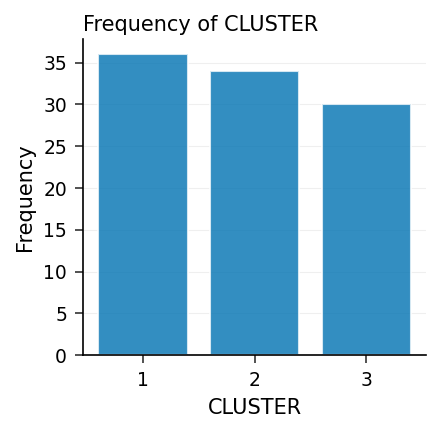

In [5]:
/* siirrä klusteritunniste takaisin alkuperäisen mittakaavan dataan */
PROSEDUURI LAJITTELE TIEDOT=scored(keep=subscriber_id CLUSTER distance) out=clus_assign;
    MUKAAN subscriber_id;
SUORITA;
PROSEDUURI LAJITTELE TIEDOT=subscribers out=subs_sorted;
    MUKAAN subscriber_id;
SUORITA;
TIEDOT profile;
    YHDISTÄ subs_sorted clus_assign;
    MUKAAN subscriber_id;
SUORITA;

/* Kuinka moni tilaaja päätyi kuhunkin segmenttiin? */
PROSEDUURI FREKVENSSIT TIEDOT=profile;
    NIMIKE CLUSTER='Segmentti';
    TABLES CLUSTER / nocum;
SUORITA;


## 6. Profiloi segmentit

Klusteritunnisteet ovat merkityksettömiä, kunnes kuvaamme *käyttäytymisen* kunkin sisällä. Alkuperäisten (standardoimattomien) muuttujien keskiarvo `CLUSTER`in mukaan paljastaa persoonan kunkin segmentin takana -- kuka suoratoistaa, kuka puhuu, kuka tuskin käyttää verkkoa -- ja kategorinen jakauma näyttää, mitkä liittymätyypit ja alueet keskittyvät kuhunkin segmenttiin.

                                                  The MEANS Procedure

                                    Analysis Variable : tenure_months Asiakkuus (kk)

        Segmentti          N Obs           Mean
        ---------------------------------------
        1                     36           28.9
        2                     34           25.8
        3                     30           28.1
        ---------------------------------------

                                    Analysis Variable : monthly_data_gb Data (Gt/kk)

        Segmentti          N Obs           Mean
        ---------------------------------------
        1                     36            4.0
        2                     34           10.2
        3                     30           44.4
        ---------------------------------------

                                     Analysis Variable : voice_minutes Puheminuutit

        Segmentti          N Obs           Mean
        --------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


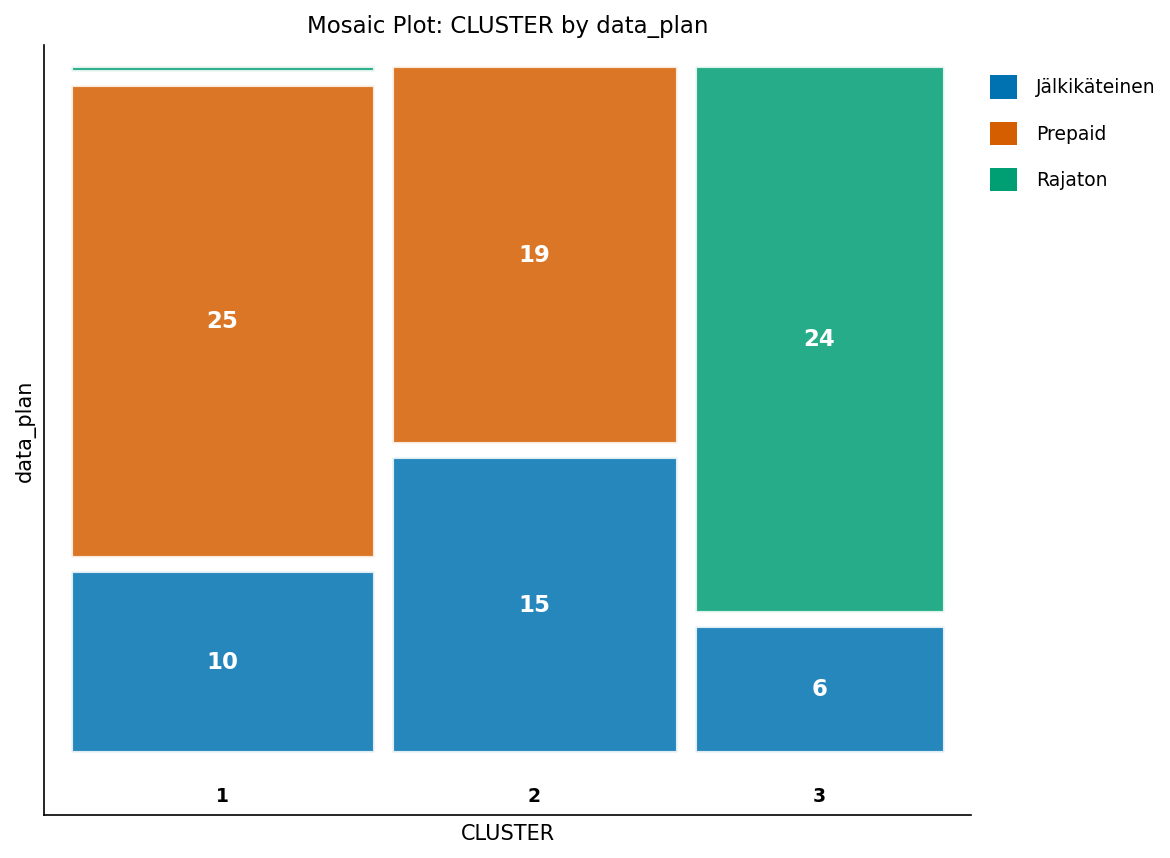

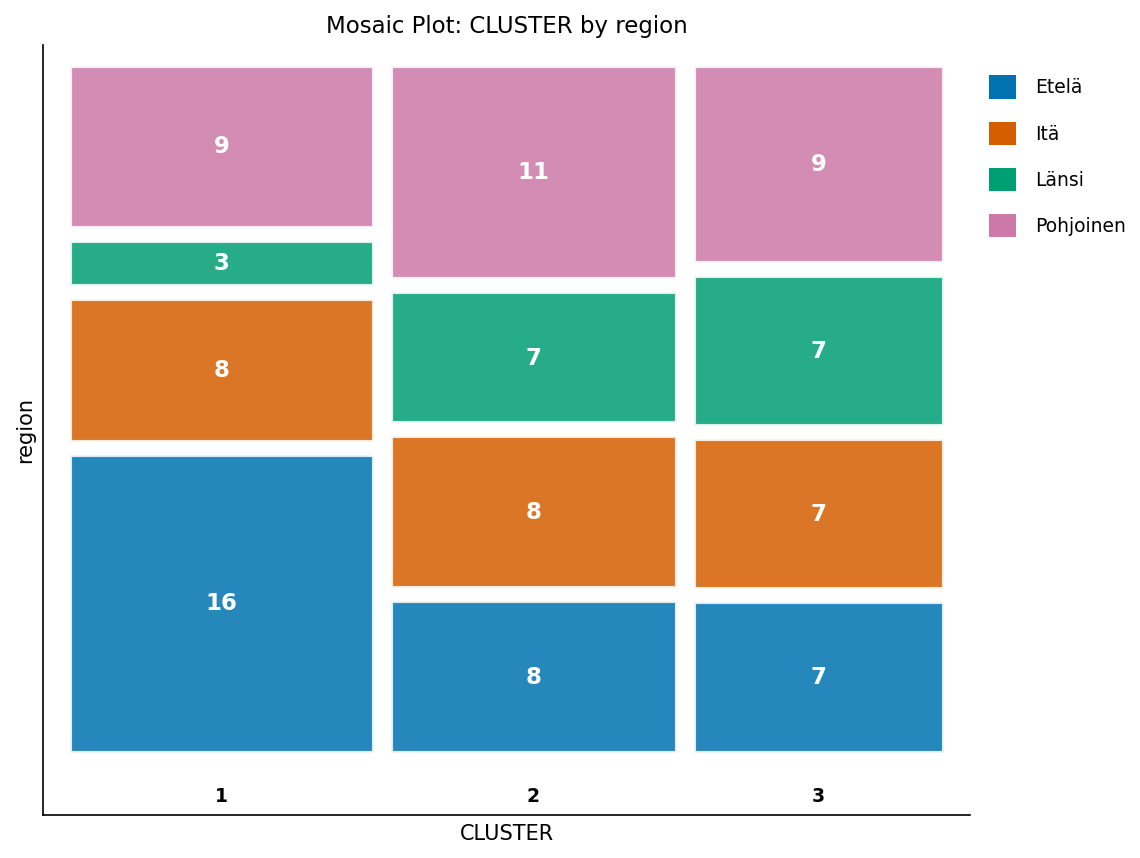

In [6]:
/* Käyttäytymisprofiili: kunkin muuttujan keskiarvo segmentin mukaan */
PROSEDUURI KESKIARVOT TIEDOT=profile n mean maxdec=1;
    LUOKKA CLUSTER;
    NIMIKE CLUSTER='Segmentti' tenure_months='Asiakkuus (kk)'
          monthly_data_gb='Data (Gt/kk)' voice_minutes='Puheminuutit'
          sms_count='Tekstiviestit' intl_minutes='Ulkomaanminuutit'
          arpu='ARPU ($)' support_calls='Tukipyynnöt';
    MUUTTUJA tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
SUORITA;

/* Kategorinen jakauma kunkin segmentin sisällä */
PROSEDUURI FREKVENSSIT TIEDOT=profile;
    NIMIKE CLUSTER='Segmentti' data_plan='Liittymätyyppi' region='Alue';
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
SUORITA;


## 7. Visualisoi segmentit

Kuva tekee segmentoinnista konkreettisen. Piirrämme dataruokahalun puhekäyttöä vastaan, väritettynä segmentin mukaan, ja lisäämme ARPU:n laatikkokuvion segmenttiä kohti, jotta tulotarina on selvä yhdellä silmäyksellä.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


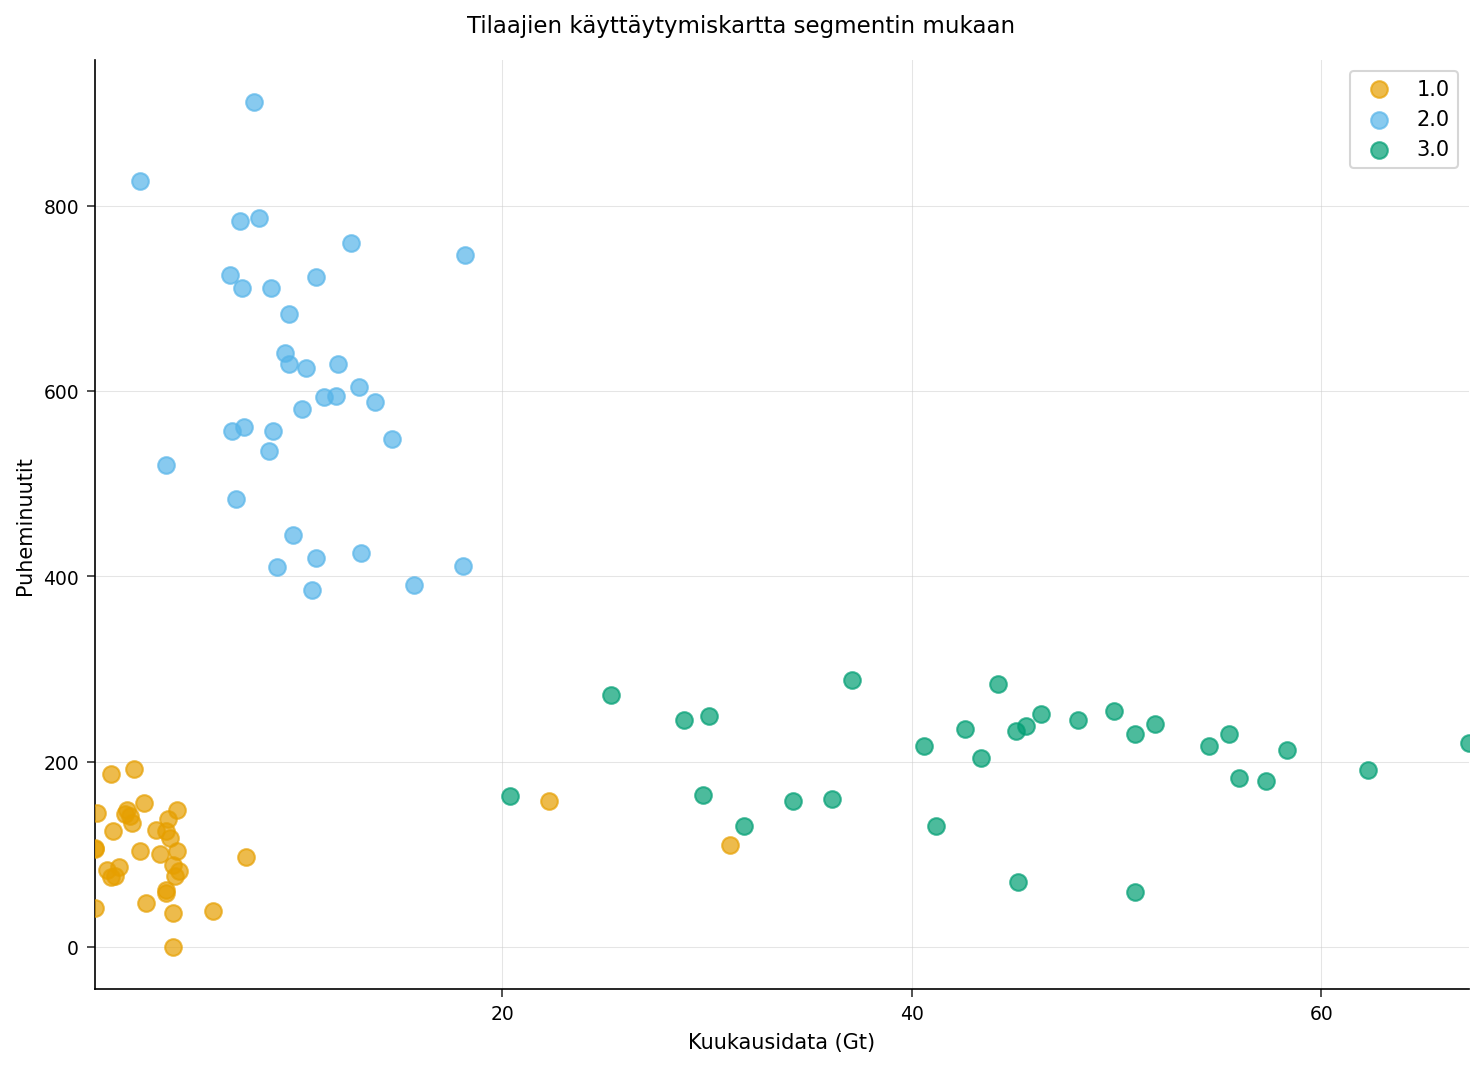

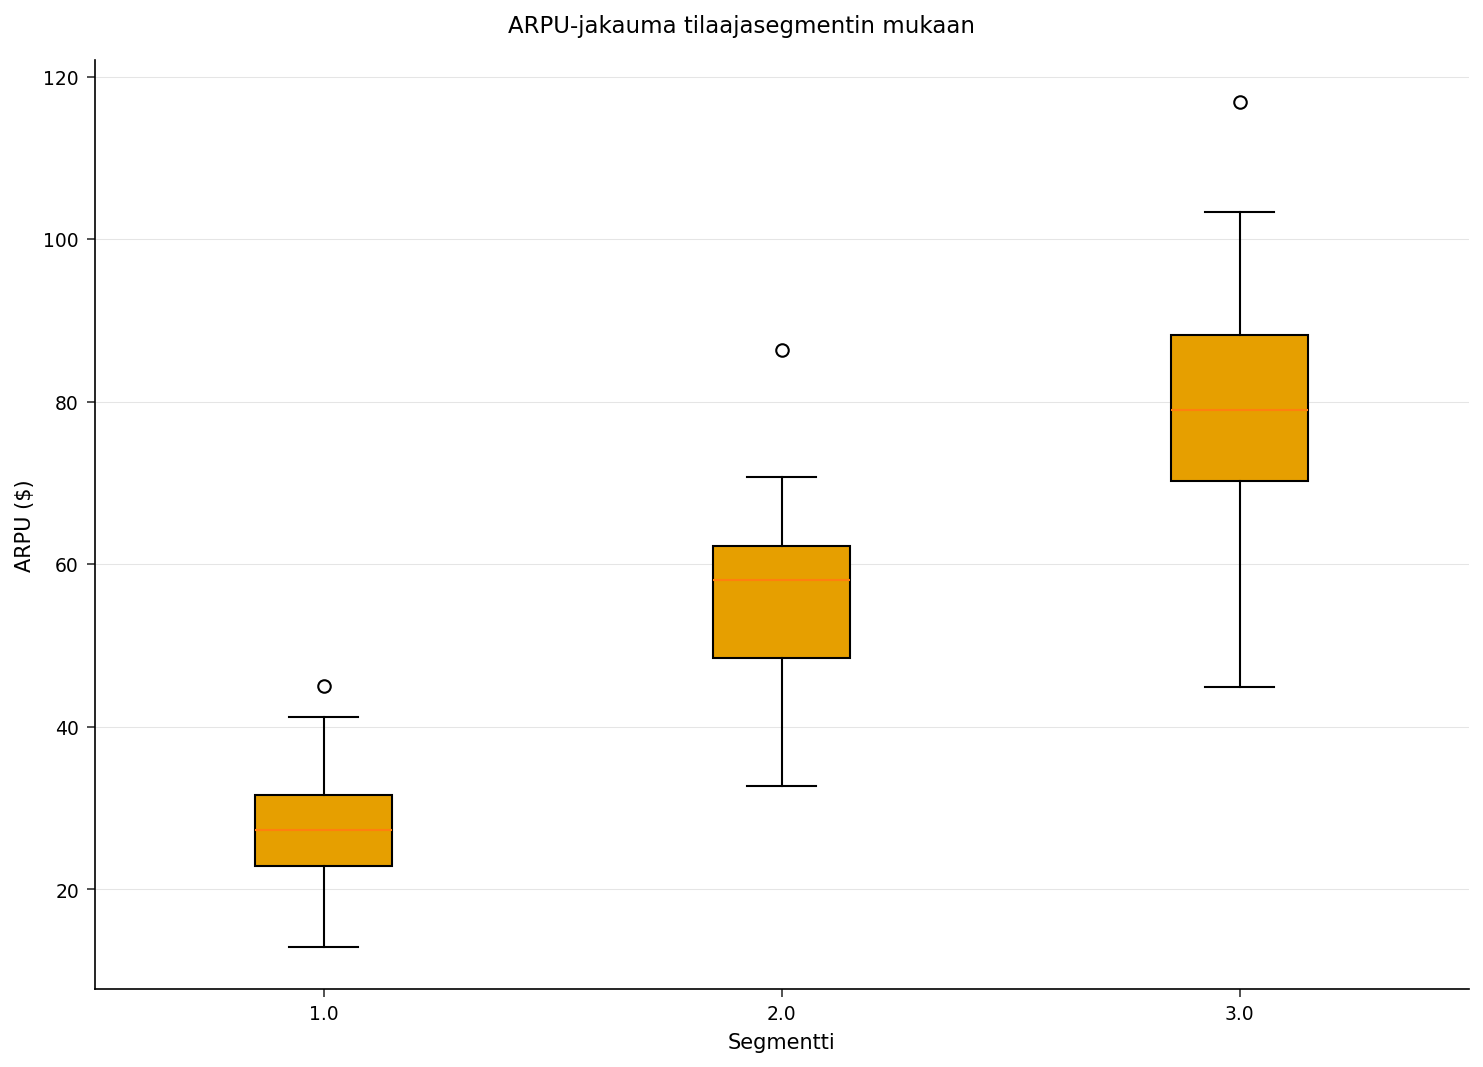

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Käyttäytymiskartta: data vs. puhe, väritettynä segmentin mukaan */
PROSEDUURI SGPLOT TIEDOT=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS label="Kuukausidata (Gt)" grid;
    YAXIS label="Puheminuutit"      grid;
    OTSIKKO "Tilaajien käyttäytymiskartta segmentin mukaan";
SUORITA;

/* Tulojakauma segmenttiä kohti */
PROSEDUURI SGPLOT TIEDOT=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS label="Segmentti";
    YAXIS label="ARPU ($)" grid;
    OTSIKKO "ARPU-jakauma tilaajasegmentin mukaan";
SUORITA;


## 8. Vie pisteytetyt segmentit

Lopuksi luovutamme luokittelut jatkokäsittelyyn CRM- ja kampanjajärjestelmiin. Säilytämme tunnisteen, klusteritunnisteen ja tärkeimmät käyttäytymiskentät.

In [8]:
/* Tallenna segmenttiluokittelut aktivointia varten */
TIEDOT subscriber_segments;
    ASETA profile;
    SÄILYTÄ subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=subscriber_segments(obs=10) noobs NIMIKE;
    NIMIKE subscriber_id='Tilaaja' CLUSTER='Segmentti'
          tenure_months='Asiakkuus (kk)' monthly_data_gb='Data (Gt/kk)'
          voice_minutes='Puheminuutit' arpu='ARPU ($)'
          data_plan='Liittymätyyppi' region='Alue';
    OTSIKKO "Otos pisteytetyistä tilaajasegmenteistä";
SUORITA;


                                        Otos pisteytetyistä tilaajasegmenteistä                                         

Tilaaja  Segmentti  Asiakkuus (kk)  Data (Gt/kk)  Puheminuutit  ARPU ($)   Liittymätyyppi       Alue
 100001          1              30           2.3           104        28  Prepaid          Etelä
 100002          2               8          10.2           581     57.78  Prepaid          Länsi
 100003          2               8          10.7           385     55.66  Jälkikäteinen    Pohjoinen
 100004          2              68           7.4           561     70.68  Prepaid          Pohjoinen
 100005          3              18          45.6           239     63.85  Rajaton          Pohjoinen
 100006          3              10          30.1           249     88.33  Rajaton          Itä
 100007          1              62           0.7            83     21.26  Prepaid          Etelä
 100008          1              68             2           192     29.93  Jälkikäteinen 


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Tulosten tulkinta

`PROC FASTCLUS` löysi kolme selkeää, hyvin erottuvaa segmenttiä. Sovitus on luotettava: **kokonais-R-neliö on 0,575** ja **pseudo-F on 65,75**, mikä tarkoittaa, että kolme klusteria selittävät noin 58 % standardoitujen muuttujien kokonaisvaihtelusta. Erottelu johtuu lähes kokonaan käyttäytymissignaaleista, joista olemme kiinnostuneita -- `voice_minutes` (R-neliö 0,858), `monthly_data_gb` (0,844) ja `arpu` (0,771) kantavat segmentoinnin, kun taas `tenure_months` (0,000) ja `support_calls` (0,193) eivät juuri vaikuta mihinkään, mikä vahvistaa, että *miten* tilaaja käyttää verkkoa -- ei se, kuinka kauan hän on ollut asiakas -- määrittelee persoonat.

Kolme segmenttiä vastaavat suoraan markkinointivalmiita persoonia, profiloituna tässä alkuperäisellä (standardoimattomalla) asteikolla:

| Segmentti | n (osuus) | Tunnusomainen käyttäytyminen | Liittymäjakauma | Persoona | Suositeltu toimenpide |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30 %) | Eniten dataa: **44,4 Gt/kk**, suurin kulutus **79,1 $ ARPU**, kohtalainen puhe (205 min) | 24/30 **Rajaton** | **Paljon dataa suoratoistavat** | Suojele ja lisämyy: nopeammat tasot, sisältöpaketit, laitepäivitykset |
| **2** | 34 (34 %) | Eniten puhetta **603 min/kk**, **214 tekstiviestiä**, **106 ulkomaanmin**, keskikulutus **55,9 $ ARPU** | Prepaid + Jälkikäteinen, **ei lainkaan Rajatonta** | **Puhekeskeiset perinteikkäät** | Ulkomaanlisät, perhe-/puhepaketit, kanta-asiakasedut |
| **1** | 36 (36 %) | Vähäisin käyttö: **4,0 Gt**, 104 puheminuuttia, pienin kulutus **28,0 $ ARPU** | 25/36 **Prepaid** | **Kevyt / vähäinen käyttö** | Oikean kokoiset liittymät, automaattiveloitusmuistutukset, edulliset datapaketit käytön kasvattamiseksi |

Liittymäjakauma vahvistaa käyttäytymistulkinnan: paljon dataa käyttävä segmentti on ylivoimaisesti **Rajaton**-liittymillä (24/30), puhekeskeisellä segmentillä **ei ole lainkaan** Rajaton-tilaajia, ja vähäisen käytön segmentti on enimmäkseen **Prepaid** (25/36). Alue sen sijaan jakautuu tasaisesti kaikkien kolmen segmentin kesken -- maantiede ei ole täällä käyttäytymisen ajuri, mikä on itsessään hyödyllinen havainto kampanjoiden kohdentamiseen.

**Miksi `PROC FASTCLUS` sopii tähän ongelmaan.** Se ajaa erillisen k-means-menetelmän käymällä datan läpi kerran sen sijaan, että materialisoisi täyden etäisyysmatriisin, joten sama ohjelma, joka segmentoi nämä 100 tilaajaa, skaalautuu erittäin suuriin joukkoihin. Standardointi `PROC STDIZE`llä ensin poisti yksikkömittakaavan vinouman gigatavujen, minuuttien ja dollarien välillä, jotta jokainen käyttäytymispiirre vaikutti yhtäläisesti euklidiseen etäisyyteen; R-neliödiagnostiikka kertoi sitten, *mitkä* muuttujat todella ajoivat jaon. Pisteytetty tuloste -- `CLUSTER`-tunniste jokaisella tilaajalla -- siirtyy suoraan aktivointiputkiin, sulkien silmukan raakadatasta kohdennettuun tarjoukseen.

---

<div style="font-size:11px;color:#9e9e9e">Tämä muistikirja on tarkoitettu vain esittelytarkoituksiin. Data on synteettistä, eivätkä havainnot ole liiketoimintaneuvontaa.</div>